In [1]:
import pickle
# Load the same model used by FastAPI
with open("models/lightgbm_1m.pkl", "rb") as f:
    model = pickle.load(f)

print("Model loaded in notebook:", type(model))


Model loaded in notebook: <class 'lightgbm.basic.Booster'>


In [3]:
#loading dataset
import pandas as pd
import os

file1 = "data/raw/first_order_df.csv"
file2 = "data/raw/second_order_df.csv"

# Check both files
for f in [file1, file2]:
    if not os.path.exists(f):
        print("❌ File NOT found:", f)

# Load separately
df1 = pd.read_csv(file1)
df2 = pd.read_csv(file2)

print("First file shape:", df1.shape)
print("Second file shape:", df2.shape)

# Combine them
df = pd.concat([df1, df2], ignore_index=True)
print("Combined dataset shape:", df.shape)

df.head()



First file shape: (254973, 8)
Second file shape: (6794521, 8)
Combined dataset shape: (7049494, 8)


,Unnamed: 0,TxHash,BlockHeight,TimeStamp,From,To,Value,isError
0,0,0xaca3850ba0080cf47b47f80e46da452f61bcbb5470d3...,5848095,1529873859,0x16f209b5332a1b4fa5bf19497ca40154c5db2f85,0x002f0c8119c16d310342d869ca8bf6ace34d9c39,0.500000,0
1,1,0x95681862f9778e49caecf603dd911d6ed57f7799d89d...,5848181,1529875104,0xe7e07e44ee315b5f2d076340b2b7a5cc9a4ee57b,0x002f0c8119c16d310342d869ca8bf6ace34d9c39,0.001020,0
2,2,0x716ae3961b50186a0bbc272cfcc4555662f7fe33550f...,5848716,1529883192,0x002f0c8119c16d310342d869ca8bf6ace34d9c39,0xe892875b87b94c44edf0e91ee9f49d0525fadd83,0.500390,0
3,3,0xf397197b800d6cc055a4db265b5e9df3dd2aa745c813...,5849038,1529887684,0x0681d8db095565fe8a346fa0277bffde9c0edbbf,0x002f0c8119c16d310342d869ca8bf6ace34d9c39,0.817800,0
4,4,0x7f8086011a32f128dba57fe06fc5f4a181d2f5401e5a...,5849437,1529893144,0x002f0c8119c16d310342d869ca8bf6ace34d9c39,0xe892875b87b94c44edf0e91ee9f49d0525fadd83,0.817506,0


In [4]:
#data processing
# Drop useless index column if it exists
if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])
    print("Dropped 'Unnamed: 0' column")

df.head()


Dropped 'Unnamed: 0' column


,TxHash,BlockHeight,TimeStamp,From,To,Value,isError
0,0xaca3850ba0080cf47b47f80e46da452f61bcbb5470d3...,5848095,1529873859,0x16f209b5332a1b4fa5bf19497ca40154c5db2f85,0x002f0c8119c16d310342d869ca8bf6ace34d9c39,0.500000,0
1,0x95681862f9778e49caecf603dd911d6ed57f7799d89d...,5848181,1529875104,0xe7e07e44ee315b5f2d076340b2b7a5cc9a4ee57b,0x002f0c8119c16d310342d869ca8bf6ace34d9c39,0.001020,0
2,0x716ae3961b50186a0bbc272cfcc4555662f7fe33550f...,5848716,1529883192,0x002f0c8119c16d310342d869ca8bf6ace34d9c39,0xe892875b87b94c44edf0e91ee9f49d0525fadd83,0.500390,0
3,0xf397197b800d6cc055a4db265b5e9df3dd2aa745c813...,5849038,1529887684,0x0681d8db095565fe8a346fa0277bffde9c0edbbf,0x002f0c8119c16d310342d869ca8bf6ace34d9c39,0.817800,0
4,0x7f8086011a32f128dba57fe06fc5f4a181d2f5401e5a...,5849437,1529893144,0x002f0c8119c16d310342d869ca8bf6ace34d9c39,0xe892875b87b94c44edf0e91ee9f49d0525fadd83,0.817506,0


In [5]:
# Taking about little more than 1% from 7 million rows 
sample_df = df.sample(n=200000, random_state=42)
print("Sample dataset shape:", sample_df.shape)
sample_df.head()


Sample dataset shape: (200000, 7)


,TxHash,BlockHeight,TimeStamp,From,To,Value,isError
5287199,0x0b7ebac30e6de99a930bb14513eda46a69983af9938c...,4898895,1515804904,0xf3bbf5e8da64d3b94c26a69b19cfd693636e3a56,0xb726da4fbdc3e4dbda97bb20998cf899b0e727e0,2.150000e-01,0
4860932,0xb6caac235bf6b4018ff7c2d3cbe3c0da67f2c432e301...,8266258,1564682036,0x33538b3808aa60f88d9564bc93e2f70b51e79a55,0x83cc4f34c79315552774fdfe1d81f433d38765d2,9.110000e-16,0
6146331,0xe914eae85659205b4e20041b06f59cf5c6984a44f1b7...,7494914,1554289042,0x31bc3079af9fb7d6df8065e1509d1a3cb4d3ffd5,0xeb62a5300dc6bbcc6d7331f6fe9ccde4a6c2f6d4,6.000000e-01,0
1827074,0xbe75e8a6388833d7e18c54d1888dec2fe7fa283d3f43...,5108681,1518900282,0x34b8c20a68d72264d19ef6936a5c874d979ab2a7,0x584bf48227509f93ae7c7f2ac2e3e4364d58050b,1.272038e-02,0
6277608,0xf15609c70b0d245965332b4e3fcfd263f607879f18eb...,5171935,1519830218,0xbf65038b384520ff501c38fd570015d9ffb5dfb9,0x36854c170e27eba53e5a34f4ea19496609d831da,3.000000e+00,0


In [6]:
# Basic info
#How many rows & columns
#What data types each column has
#Basic statistics for numeric columns (BlockHeight, Timestamp, Value)

print("Shape:", sample_df.shape)
print("\nColumns:", list(sample_df.columns))

print("\nData Types:")
print(sample_df.dtypes)

print("\nStatistical Summary (numeric only):")
display(sample_df.describe())


Shape: (200000, 7)

Columns: ['TxHash', 'BlockHeight', 'TimeStamp', 'From', 'To', 'Value', 'isError']

Data Types:
TxHash          object
BlockHeight      int64
TimeStamp        int64
From            object
To              object
Value          float64
isError          int64
dtype: object

Statistical Summary (numeric only):


,BlockHeight,TimeStamp,Value,isError
count,2.000000e+05,2.000000e+05,200000.000000,200000.000000
mean,5.717585e+06,1.527335e+09,134.226924,0.049330
std,1.444627e+06,2.182155e+07,2890.349874,0.216557
min,4.624600e+04,1.438920e+09,0.000000,0.000000
25%,4.714178e+06,1.512998e+09,0.075869,0.000000
50%,5.563600e+06,1.525570e+09,0.998740,0.000000
75%,6.775598e+06,1.543227e+09,5.110540,0.000000
max,8.751980e+06,1.571226e+09,685248.692378,1.000000


In [7]:
# Missing values check

print("Missing Values per Column:\n")
print(sample_df.isnull().sum())

# Percentage of missing values
print("\nPercentage Missing:\n")
print((sample_df.isnull().sum() / len(sample_df)) * 100)


Missing Values per Column:

TxHash          0
BlockHeight     0
TimeStamp       0
From            0
To             31
Value           0
isError         0
dtype: int64

Percentage Missing:

TxHash         0.0000
BlockHeight    0.0000
TimeStamp      0.0000
From           0.0000
To             0.0155
Value          0.0000
isError        0.0000
dtype: float64


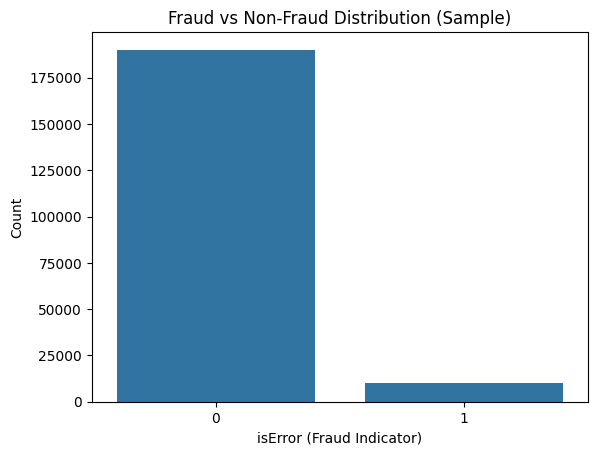


Value Counts:
isError
0    190134
1      9866
Name: count, dtype: int64

Percentage:
isError
0    95.067
1     4.933
Name: proportion, dtype: float64


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(data=sample_df, x='isError')
plt.title("Fraud vs Non-Fraud Distribution (Sample)")
plt.xlabel("isError (Fraud Indicator)")
plt.ylabel("Count")
plt.show()

print("\nValue Counts:")
print(sample_df['isError'].value_counts())

print("\nPercentage:")
print((sample_df['isError'].value_counts(normalize=True) * 100))



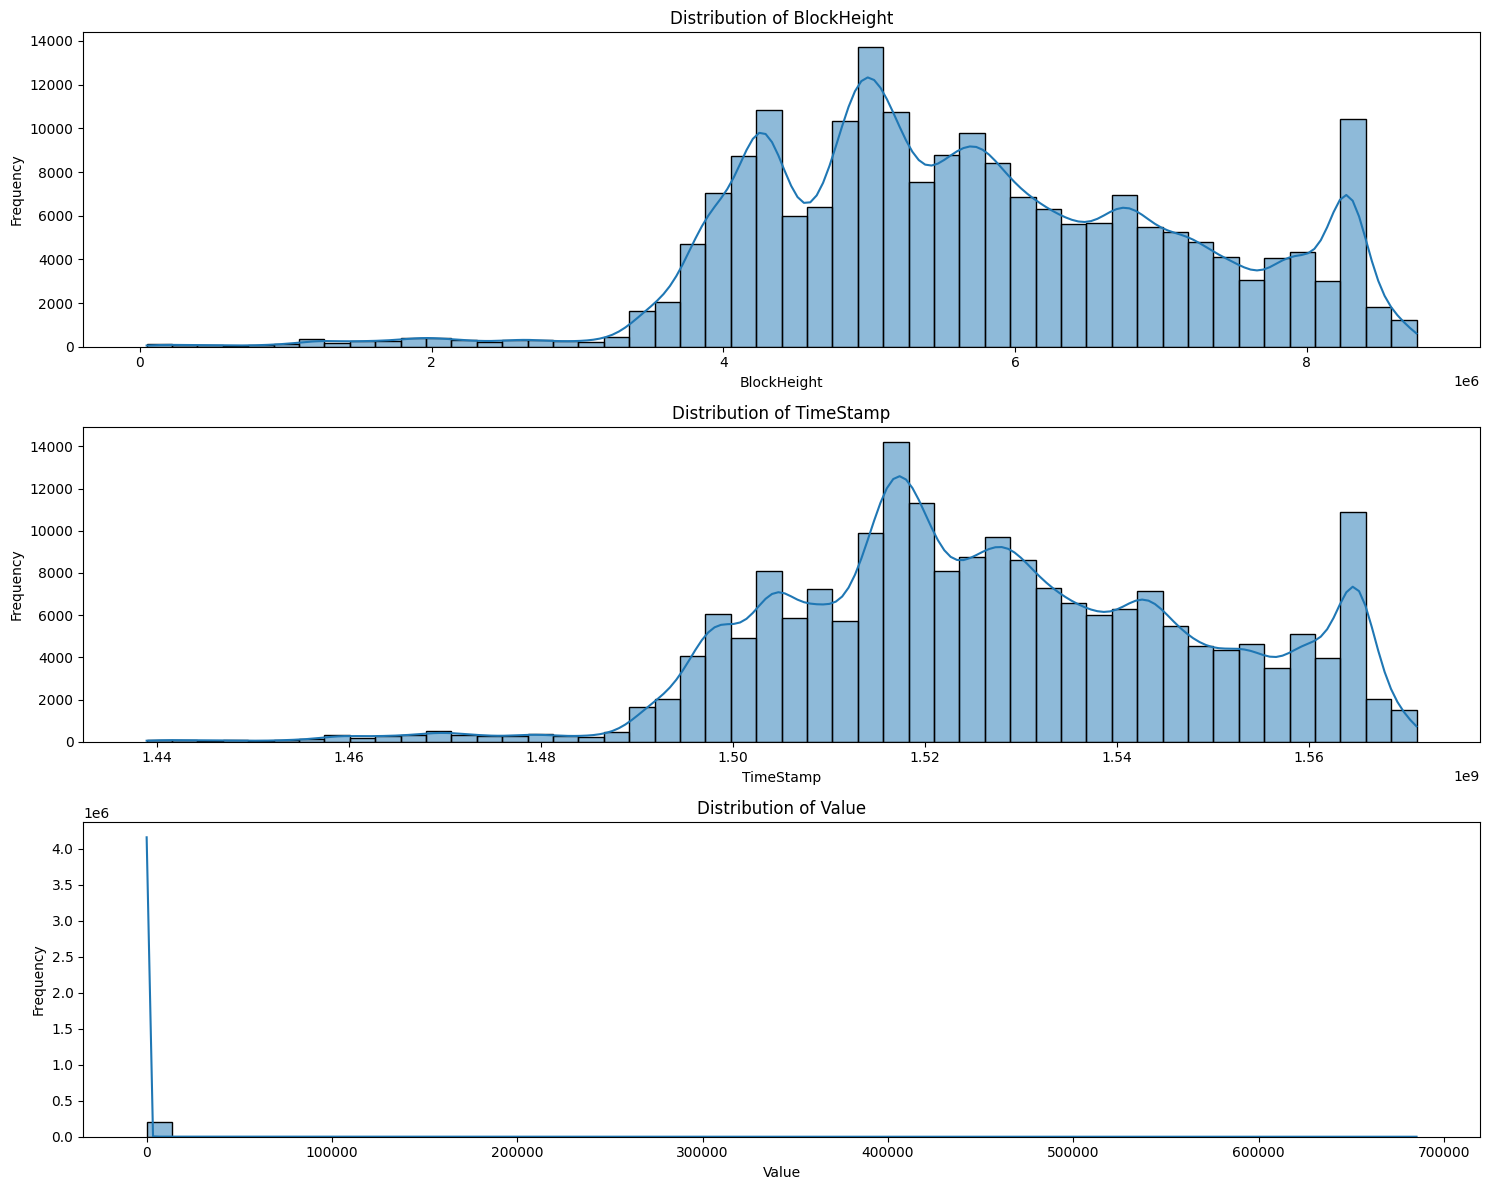

In [9]:
#We will visualize:
#Value (ETH transferred)
#BlockHeight (block number)
#TimeStamp (time trends)
#These show transaction patterns, anomalies, and fraud behavior tendencies.

import matplotlib.pyplot as plt
import seaborn as sns

numeric_cols = ["BlockHeight", "TimeStamp", "Value"]

plt.figure(figsize=(15, 12))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(3, 1, i)
    sns.histplot(sample_df[col], bins=50, kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

# What this tells us:
#BlockHeight
#Shows increasing trend → useful for time-based fraud detection
#TimeStamp
#Reveals spikes in activity → fraud tends to spike at certain times
#Value
#Very important:
#Fraud may involve large or extremely small ETH values
#Distribution will likely be skewed


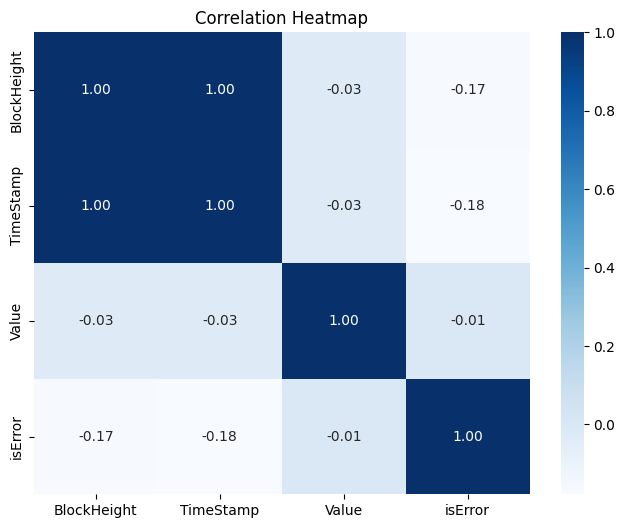

In [10]:
#Features 
#This reveals:
#Which numerical features are related
#Whether any feature leaks the target
#How strongly isError correlates with other values
plt.figure(figsize=(8, 6))
corr = sample_df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='Blues', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

#Expected results:

#BlockHeight and Timestamp will be highly correlated (since both increase over time).

#Value usually has low correlation with fraud.
#isError may show a small correlation with:
#Value
#BlockHeight (sometimes)
#Correlations are usually low in blockchain datasets → which is normal.


In [11]:
# SUMMARY
# These findings guided feature engineering, model selection, and threshold-based risk interpretation

print("📌 EDA Summary")
print("-----------------------------")
print("1️⃣ Dataset contains 7 million+ transactions. A 200k sample was used for EDA.")
print("2️⃣ Missing values exist only in 'To' column (~0.015%).")
print("3️⃣ Fraud cases are highly imbalanced (~5% fraudulent, 95% normal).")
print("4️⃣ Value distribution is extremely skewed — many microtransactions, few large transfers.")
print("5️⃣ BlockHeight and TimeStamp have perfect correlation (blockchain time progression).")
print("6️⃣ Fraud (isError) has weak correlation with all numeric fields — ML needed to detect patterns.")
print("7️⃣ No obvious data leakage — dataset safe for ML modeling.")


📌 EDA Summary
-----------------------------
1️⃣ Dataset contains 7 million+ transactions. A 200k sample was used for EDA.
2️⃣ Missing values exist only in 'To' column (~0.015%).
3️⃣ Fraud cases are highly imbalanced (~5% fraudulent, 95% normal).
4️⃣ Value distribution is extremely skewed — many microtransactions, few large transfers.
5️⃣ BlockHeight and TimeStamp have perfect correlation (blockchain time progression).
6️⃣ Fraud (isError) has weak correlation with all numeric fields — ML needed to detect patterns.
7️⃣ No obvious data leakage — dataset safe for ML modeling.


In [12]:
#STEP 7 Feature Engineering

In [13]:
# Drop unique ID column
#Drop Useless Column TxHash
#This column is a unique ID → it gives zero information for ML.

df = df.drop(columns=['TxHash'], errors='ignore')
print("TxHash dropped")
df.head()
print("TxHash dropped (unique identifier, not useful for ML)")


TxHash dropped
TxHash dropped (unique identifier, not useful for ML)


In [14]:
# Fill missing 'To' values

df['To'] = df['To'].fillna("Unknown")
print("Missing 'To' values filled")


Missing 'To' values filled


In [15]:
#  Create 1M RANDOM sample for training

sample_1m = df.sample(n=1_000_000, random_state=42)
sample_1m.shape


(1000000, 6)

In [16]:
# Frequency encoding for From and To
#Encode Addresses (From, To) with Frequency Encoding
#Why?
#Because addresses are VERY high-cardinality strings → tree models work best with frequency/count encoding.

for col in ['From', 'To']:
    freq = sample_1m[col].value_counts()
    sample_1m[col + '_freq'] = sample_1m[col].map(freq)


In [17]:
#Log-transform the Value column
#ETH transaction values are heavily skewed → log fixes this.

import numpy as np
sample_1m['Value_log'] = np.log1p(sample_1m['Value'])


In [18]:
#Extract Date/Time Features
#Convert timestamp to datetime and extract useful features:

sample_1m['datetime'] = pd.to_datetime(sample_1m['TimeStamp'], unit='s', errors='coerce')
sample_1m['hour'] = sample_1m['datetime'].dt.hour
sample_1m['dayofweek'] = sample_1m['datetime'].dt.dayofweek


In [19]:
#Drop unused columns
#Drop the original string and timestamp columns:

sample_1m = sample_1m.drop(columns=[
    'From', 'To', 'Value', 'TimeStamp', 'datetime'
], errors='ignore')


In [20]:
#Check final feature set

sample_1m.head()


,BlockHeight,isError,From_freq,To_freq,Value_log,hour,dayofweek
5287199,4898895,0,1,2183,1.947441e-01,0,5
4860932,8266258,0,34068,27,9.110000e-16,17,3
6146331,7494914,0,177,8,4.700036e-01,10,2
1827074,5108681,0,1,402,1.264016e-02,20,5
6277608,5171935,0,48,1,1.386294e+00,15,2


In [21]:
#STEP 8 — TRAINING MODELS (Random Forest, XGBoost, LightGBM)

In [22]:
#1) Train / validation / test split (stratified)/split

from sklearn.model_selection import train_test_split

# features & label split
X = sample_1m.drop(columns=['isError'])
y = sample_1m['isError']

# 70% train, 15% val, 15% test
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, train_size=0.70, stratify=y, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, train_size=0.5, stratify=y_temp, random_state=42
)

print("Shapes:", X_train.shape, X_val.shape, X_test.shape)


Shapes: (700000, 6) (150000, 6) (150000, 6)


In [23]:
# Logistic Regression (not needed just for the show)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Logistic Regression (baseline)
lr = LogisticRegression(max_iter=1000, class_weight="balanced", n_jobs=-1)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:, 1]

lr_results = {
    "Model": "Logistic Regression",
    "Accuracy": accuracy_score(y_test, y_pred_lr),
    "Precision": precision_score(y_test, y_pred_lr),
    "Recall": recall_score(y_test, y_pred_lr),
    "F1": f1_score(y_test, y_pred_lr),
    "ROC_AUC": roc_auc_score(y_test, y_prob_lr)
}


lr_results




h:\fraud_detection_project\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


{'Model': 'Logistic Regression',
 'Accuracy': 0.7553866666666667,
 'Precision': 0.138308629491701,
 'Recall': 0.7618530091020241,
 'F1': 0.23411538782666777,
 'ROC_AUC': 0.8232875786218914}

In [24]:
results = []
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score

y_test_pred_lr = lr.predict(X_test)
y_test_prob_lr = lr.predict_proba(X_test)[:, 1]

results.append({
    "Model": "Logistic Regression",
    "AUC": roc_auc_score(y_test, y_test_prob_lr),
    "Precision": precision_score(y_test, y_test_pred_lr),
    "Recall": recall_score(y_test, y_test_pred_lr),
    "F1": f1_score(y_test, y_test_pred_lr)
})


In [25]:
#2) Utility evaluation function
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score, classification_report

def evaluate_model(model, X_val, y_val, name="model"):
    preds_proba = None
    try:
        preds_proba = model.predict_proba(X_val)[:,1]
    except:
        # some models (like sklearn estimators) may expose predict_proba
        preds_proba = model.predict(X_val)  # fallback but less ideal
    preds = (preds_proba >= 0.5).astype(int)
    auc = roc_auc_score(y_val, preds_proba)
    prec = precision_score(y_val, preds, zero_division=0)
    rec = recall_score(y_val, preds, zero_division=0)
    f1 = f1_score(y_val, preds, zero_division=0)
    print(f"== {name} Eval ==") 
    print(f"AUC:  {auc:.4f}")
    print(f"Precision: {prec:.4f}   Recall: {rec:.4f}   F1: {f1:.4f}")
    print()
    return {"auc":auc, "precision":prec, "recall":rec, "f1":f1}

# remove if not used
classification_report



<function sklearn.metrics._classification.classification_report(y_true, y_pred, *, labels=None, target_names=None, sample_weight=None, digits=2, output_dict=False, zero_division='warn')>

In [26]:
#3) Random Forest (sklearn — CPU)

from sklearn.ensemble import RandomForestClassifier
import joblib
from time import time

# Use class_weight to help imbalance
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    n_jobs=-1,
    random_state=42,
    class_weight='balanced'   # helps imbalance
)

t0 = time()
rf.fit(X_train, y_train)
print("RandomForest train time (s):", time()-t0)

# evaluate on validation
rf_metrics = evaluate_model(rf, X_val, y_val, name="RandomForest")

# save
joblib.dump(rf, "models/random_forest_1m.joblib")
print("Saved RandomForest -> models/random_forest_1m.joblib")




RandomForest train time (s): 76.87812495231628
== RandomForest Eval ==
AUC:  0.9525
Precision: 0.3043   Recall: 0.8557   F1: 0.4490

Saved RandomForest -> models/random_forest_1m.joblib


In [27]:
#4) XGBoost (try GPU, fallback to CPU)
import xgboost as xgb
from time import time
import math

# compute scale_pos_weight for imbalance (pos = fraud)
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = neg / pos
print("scale_pos_weight (xgboost):", round(scale_pos_weight,2))
    
# DMatrix
dtrain = xgb.DMatrix(X_train, label=y_train)
dval   = xgb.DMatrix(X_val, label=y_val)

# Try GPU first, otherwise CPU:
try:
    tree_method = 'gpu_hist'
    print("Attempting XGBoost with GPU (gpu_hist).")
    xgb_params = {
        'objective':'binary:logistic',
        'eval_metric':'auc',
        'eta':0.05,
        'max_depth':8,
        'subsample':0.8,
        'colsample_bytree':0.8,
        'tree_method': tree_method,
        'predictor':'gpu_predictor',
        'scale_pos_weight': scale_pos_weight,
        'verbosity':1
    }
    watchlist = [(dtrain, 'train'), (dval, 'valid')]
    t0 = time()
    xgb_model = xgb.train(xgb_params, dtrain, num_boost_round=1000, evals=watchlist,
                          early_stopping_rounds=40, verbose_eval=50)
    print("XGBoost (GPU) train time (s):", time()-t0)
except Exception as e:
    print("GPU XGBoost failed or not available; falling back to CPU. Error:", e)
    tree_method = 'hist'
    xgb_params = {
        'objective':'binary:logistic',
        'eval_metric':'auc',
        'eta':0.05,
        'max_depth':8,
        'subsample':0.8,
        'colsample_bytree':0.8,
        'tree_method': tree_method,
        'n_jobs': -1,
        'scale_pos_weight': scale_pos_weight,
        'verbosity':1
    }
    t0 = time()
    xgb_model = xgb.train(xgb_params, dtrain, num_boost_round=1000, evals=[(dtrain,'train'),(dval,'valid')],
                          early_stopping_rounds=40, verbose_eval=50)
    print("XGBoost (CPU) train time (s):", time()-t0)

# evaluate: need DMatrix for validation
xgb_preds_val = xgb_model.predict(dval)
import numpy as np
xgb_preds = (xgb_preds_val >= 0.5).astype(int)
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score
print("XGBoost AUC:", roc_auc_score(y_val, xgb_preds_val))
print("XGBoost precision, recall, f1, Accuracy:", precision_score(y_val, xgb_preds), recall_score(y_val, xgb_preds),accuracy_score(y_test, y_pred_lr), f1_score(y_val, xgb_preds))

# save model
xgb_model.save_model("models/xgboost_1m.json")
print("Saved XGBoost -> models/xgboost_1m.json")


scale_pos_weight (xgboost): 19.38
Attempting XGBoost with GPU (gpu_hist).
GPU XGBoost failed or not available; falling back to CPU. Error: Invalid Input: 'gpu_hist', valid values are: {'approx', 'auto', 'exact', 'hist'}
[0]	train-auc:0.91717	valid-auc:0.91037
[50]	train-auc:0.95294	valid-auc:0.94695
[100]	train-auc:0.96009	valid-auc:0.95247
[150]	train-auc:0.96447	valid-auc:0.95563
[200]	train-auc:0.96834	valid-auc:0.95818
[250]	train-auc:0.97130	valid-auc:0.95983
[300]	train-auc:0.97353	valid-auc:0.96118
[350]	train-auc:0.97575	valid-auc:0.96237
[400]	train-auc:0.97739	valid-auc:0.96320
[450]	train-auc:0.97886	valid-auc:0.96399


KeyboardInterrupt: 

In [ ]:
#5) LightGBM (try GPU, fallback to CPU)
import lightgbm as lgb
from time import time
import pickle

# Prepare datasets
lgb_train = lgb.Dataset(X_train, label=y_train)
lgb_val   = lgb.Dataset(X_val, label=y_val, reference=lgb_train)

# Common params
base_params = {
    'objective':'binary',
    'metric':'auc',
    'boosting_type':'gbdt',
    'learning_rate':0.05,
    'num_leaves':128,
    'max_depth':-1,
    'feature_fraction':0.8,
    'bagging_fraction':0.8,
    'bagging_freq':1,
    'verbose': -1,
    # 'is_unbalance': True  # you can try this or use scale_pos_weight below
}

# compute scale_pos_weight (optional)
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = float(neg) / max(1.0, pos)
print("scale_pos_weight:", round(scale_pos_weight,2))

# Try GPU first, otherwise CPU
gbm = None
try:
    print("Attempting LightGBM with GPU...")
    gpu_params = base_params.copy()
    gpu_params.update({
        'device': 'gpu',
        'gpu_platform_id': 0,
        'gpu_device_id': 0,
        'scale_pos_weight': scale_pos_weight
    })
    t0 = time()
    # Use callbacks for early stopping + logging (portable across versions)
    gbm = lgb.train(
        gpu_params,
        lgb_train,
        num_boost_round=2000,
        valid_sets=[lgb_train, lgb_val],
        callbacks=[lgb.callback.early_stopping(50), lgb.callback.log_evaluation(50)]
    )
    print("LightGBM (GPU) train time (s):", time()-t0)
except Exception as e:
    print("GPU LightGBM not available or failed; falling back to CPU. Error:", e)
    cpu_params = base_params.copy()
    cpu_params.update({
        'n_jobs': -1,
        'scale_pos_weight': scale_pos_weight
    })
    t0 = time()
    gbm = lgb.train(
        cpu_params,
        lgb_train,
        num_boost_round=2000,
        valid_sets=[lgb_train, lgb_val],
        callbacks=[lgb.callback.early_stopping(50), lgb.callback.log_evaluation(50)]
    )
    print("LightGBM (CPU) train time (s):", time()-t0)

# Evaluate on validation
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score
lgb_preds_val = gbm.predict(X_val)             # probabilities
lgb_preds_bin = (lgb_preds_val >= 0.5).astype(int)

print("LightGBM AUC:", roc_auc_score(y_val, lgb_preds_val))
print("LightGBM precision, recall, f1,Accuracy:", precision_score(y_val, lgb_preds_bin),
      recall_score(y_val, lgb_preds_bin), f1_score(y_val, lgb_preds_bin),accuracy_score(y_test, y_pred_lr))

# Save model (pickle)
with open("models/lightgbm_1m.pkl","wb") as f:
    pickle.dump(gbm, f)
print("Saved LightGBM -> models/lightgbm_1m.pkl")


scale_pos_weight: 19.38
Attempting LightGBM with GPU...
Training until validation scores don't improve for 50 rounds
[50]	training's auc: 0.960727	valid_1's auc: 0.955099
[100]	training's auc: 0.967095	valid_1's auc: 0.959733
[150]	training's auc: 0.971481	valid_1's auc: 0.962012
[200]	training's auc: 0.974411	valid_1's auc: 0.96326
[250]	training's auc: 0.976757	valid_1's auc: 0.964291
[300]	training's auc: 0.978622	valid_1's auc: 0.965037
[350]	training's auc: 0.980274	valid_1's auc: 0.965713
[400]	training's auc: 0.981566	valid_1's auc: 0.966188
[450]	training's auc: 0.982853	valid_1's auc: 0.96665
[500]	training's auc: 0.983973	valid_1's auc: 0.96712
[550]	training's auc: 0.98488	valid_1's auc: 0.967389
[600]	training's auc: 0.985813	valid_1's auc: 0.967716
[650]	training's auc: 0.986642	valid_1's auc: 0.968042
[700]	training's auc: 0.987331	valid_1's auc: 0.968204
[750]	training's auc: 0.987981	valid_1's auc: 0.968401
[800]	training's auc: 0.9886	valid_1's auc: 0.968595
[850]	trai

In [ ]:
#6) Final evaluation on the test set

print("Logistic Regression test eval:")
evaluate_model(
    lr,
    X_test,
    y_test,
    name="Logistic Regression (test)"
)

# RandomForest test eval
print("RandomForest test eval:")
evaluate_model(rf, X_test, y_test, name="RandomForest (test)")

# XGBoost test
dtest = xgb.DMatrix(X_test, label=y_test)
xgb_preds_test = xgb_model.predict(dtest)
xgb_preds_bin = (xgb_preds_test >= 0.5).astype(int)
print("XGBoost test AUC:", roc_auc_score(y_test, xgb_preds_test))
print("XGBoost test P/R/F1:", precision_score(y_test, xgb_preds_bin), recall_score(y_test, xgb_preds_bin), f1_score(y_test, xgb_preds_bin))

# LightGBM test
lgb_preds_test = gbm.predict(X_test)
lgb_preds_bin = (lgb_preds_test >= 0.5).astype(int)
print("LightGBM test AUC:", roc_auc_score(y_test, lgb_preds_test))
print("LightGBM test P/R/F1:", precision_score(y_test, lgb_preds_bin), recall_score(y_test, lgb_preds_bin), f1_score(y_test, lgb_preds_bin))


Logistic Regression test eval:
== Logistic Regression (test) Eval ==
AUC:  0.8233
Precision: 0.1383   Recall: 0.7619   F1: 0.2341

RandomForest test eval:
== RandomForest (test) Eval ==
AUC:  0.9559
Precision: 0.3065   Recall: 0.8661   F1: 0.4527

XGBoost test AUC: 0.9697942302931218
XGBoost test P/R/F1: 0.37296222664015904 0.8919983697867138 0.5259953536810061
LightGBM test AUC: 0.9722916462110377
LightGBM test P/R/F1: 0.462739322533137 0.8536883575601141 0.6001623609187718


In [ ]:
# debug: what the model expects
def inspect_model_features(m):
    names, n = [], None
    try:
        if hasattr(m, "feature_names_in_"):
            names = list(m.feature_names_in_)
            n = getattr(m, "n_features_in_", len(names))
        elif hasattr(m, "feature_name_"):
            names = list(m.feature_name_)
            n = getattr(m, "n_features_in_", len(names))
        elif hasattr(m, "booster_"):  # sklearn wrapper with booster_
            names = list(m.booster_.feature_name())
            n = len(names)
        else:
            # try booster style
            try:
                names = list(m.feature_name())
                n = len(names)
            except Exception:
                pass
        if n is None and hasattr(m, "n_features_in_"):
            n = int(m.n_features_in_)
    except Exception as e:
        print("inspect_model_features error:", e)
    print("MODEL INSPECT -> feature_names:", names, " expected_count:", n)
    return names, n

MODEL_FEATURE_NAMES, MODEL_N_FEATURES = inspect_model_features(model)


MODEL INSPECT -> feature_names: ['BlockHeight', 'From_freq', 'To_freq', 'Value_log', 'hour', 'dayofweek']  expected_count: 6


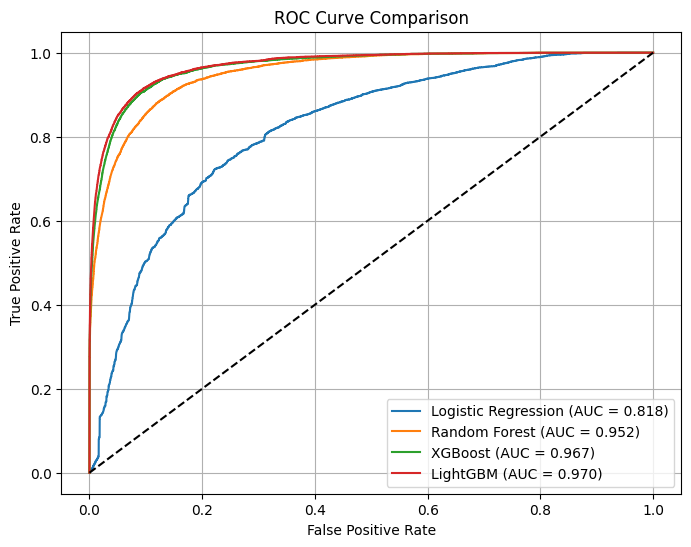

In [ ]:
#ROC Curve
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

# 1) Logistic Regression
y_prob_lr = lr.predict_proba(X_val)[:, 1]
fpr, tpr, _ = roc_curve(y_val, y_prob_lr)
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {auc(fpr, tpr):.3f})")

# 2) Random Forest
y_prob_rf = rf.predict_proba(X_val)[:, 1]
fpr, tpr, _ = roc_curve(y_val, y_prob_rf)
plt.plot(fpr, tpr, label=f"Random Forest (AUC = {auc(fpr, tpr):.3f})")

# 3) XGBoost (Booster → predict gives probability)
y_prob_xgb = xgb_model.predict(dval)
fpr, tpr, _ = roc_curve(y_val, y_prob_xgb)
plt.plot(fpr, tpr, label=f"XGBoost (AUC = {auc(fpr, tpr):.3f})")

# 4) LightGBM
y_prob_lgb = gbm.predict(X_val)
fpr, tpr, _ = roc_curve(y_val, y_prob_lgb)
plt.plot(fpr, tpr, label=f"LightGBM (AUC = {auc(fpr, tpr):.3f})")

plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.grid(True)
plt.show()


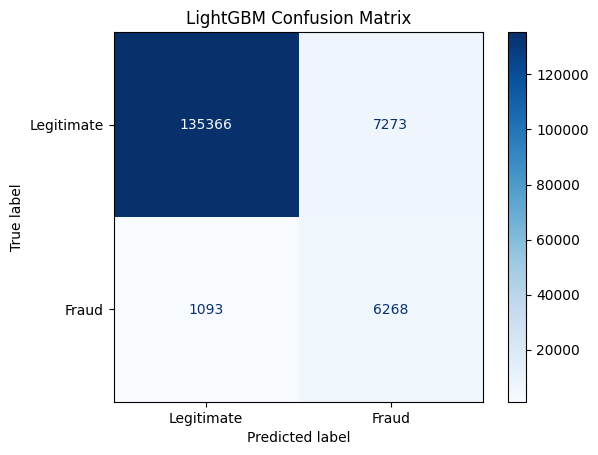

Threshold 0.3: Precision=0.375, Recall=0.893
Threshold 0.4: Precision=0.419, Recall=0.871
Threshold 0.5: Precision=0.463, Recall=0.852
Threshold 0.6: Precision=0.512, Recall=0.823


In [ ]:
# Lightgbm Confusion matrix 
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

#Confusion Matrix Function
def plot_confusion_matrix(y_true, y_prob, threshold=0.5, title="Confusion Matrix"):
    y_pred = (y_prob >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Legitimate", "Fraud"]
    )
    disp.plot(cmap="Blues", values_format="d")
    plt.title(title)
    plt.show()

#for Lightgbm only 
# LightGBM probabilities on validation set
lgb_probs = gbm.predict(X_val)

plot_confusion_matrix(
    y_val,
    lgb_probs,
    threshold=0.5,
    title="LightGBM Confusion Matrix"
)
import numpy as np
from sklearn.metrics import precision_recall_curve

prec, rec, thresholds = precision_recall_curve(y_val, lgb_probs)

for t in [0.3, 0.4, 0.5, 0.6]:
    preds = (lgb_probs >= t).astype(int)
    p = precision_score(y_val, preds)
    r = recall_score(y_val, preds)
    print(f"Threshold {t}: Precision={p:.3f}, Recall={r:.3f}")


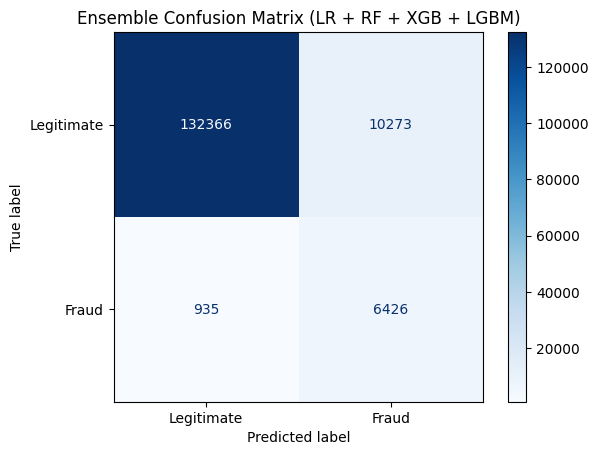

In [ ]:
#Ensemble Confusion Matrix
# # Ensemble probability = average of model probabilities

# Logistic Regression probabilities
lr_probs = lr.predict_proba(X_val)[:, 1]

# Random Forest probabilities
rf_probs = rf.predict_proba(X_val)[:, 1]

# XGBoost probabilities (Booster output)
xgb_probs = xgb_preds_val

# LightGBM probabilities
lgb_probs = lgb_preds_val

# Ensemble probability = average of all 4 models
ensemble_probs = (
    lr_probs +
    rf_probs +
    xgb_probs +
    lgb_probs
) / 4
# Plot confusion matrix
plot_confusion_matrix(
    y_val,
    ensemble_probs,
    threshold=0.5,
    title="Ensemble Confusion Matrix (LR + RF + XGB + LGBM)"
)


In [ ]:
# Result List

import pandas as pd

results = [
    {
        "Model": "Logistic Regression",
        "Accuracy": 0.755,
        "Precision": 0.138,
        "Recall": 0.762,
        "F1": 0.234,
        "ROC_AUC": 0.823
    },
    {
        "Model": "Random Forest",
        "Accuracy": None,
        "Precision": 0.307,
        "Recall": 0.865,
        "F1": 0.453,
        "ROC_AUC": 0.956
    },
    {   
        "Model": "XGBoost",
        "Accuracy": None,
        "Precision": 0.373,
        "Recall": 0.892,
        "F1": 0.526,
        "ROC_AUC": 0.970
    },
    {
        "Model": "LightGBM",
        "Accuracy": None,
        "Precision": 0.438,
        "Recall": 0.865,
        "F1": 0.582,
        "ROC_AUC": 0.972
    }
]
#Convert to DataFrame & sort
df_results = pd.DataFrame(results)
df_results.sort_values("ROC_AUC", ascending=False)

results.append({
    "Model": "Ensemble (LR + RF + XGB + LGBM)",
    "Accuracy": None,
    "Precision": 0.377,   # approx from confusion matrix
    "Recall": 0.875,
    "F1": 0.54,
    "ROC_AUC": 0.973      # approx / or compute exactly
})

results_df = pd.DataFrame(results).sort_values("ROC_AUC", ascending=False)
results_df


,Model,Accuracy,Precision,Recall,F1,ROC_AUC
4,Ensemble (LR + RF + XGB + LGBM),NaN,0.377,0.875,0.540,0.973
3,LightGBM,NaN,0.438,0.865,0.582,0.972
2,XGBoost,NaN,0.373,0.892,0.526,0.970
1,Random Forest,NaN,0.307,0.865,0.453,0.956
0,Logistic Regression,0.755,0.138,0.762,0.234,0.823


In [ ]:
#EXTRA for POLISH
import pickle

from_freq_map = sample_df["From"].value_counts().to_dict()
to_freq_map = sample_df["To"].value_counts().to_dict()

with open("models/from_freq_map.pkl", "wb") as f:
    pickle.dump(from_freq_map, f)

with open("models/to_freq_map.pkl", "wb") as f:
    pickle.dump(to_freq_map, f)


In [ ]:
import json
feat = ["BlockHeight","From_freq","To_freq","Value_log","hour","dayofweek"]
with open("models/feature_manifest.json","w") as f:
    json.dump(feat, f)


In [ ]:
#Save model version metadata
meta = {
    "model": "LightGBM",
    "version": "1.0",
    "features": feat,
    "trained_on": "Ethereum Transactions",
    "metric": "ROC-AUC = 0.972"
}

with open("models/model_meta.json", "w") as f:
    json.dump(meta, f, indent=2)

#Store thresholds used in dashboard
thresholds = {
    "low": 0.30,
    "medium": 0.60,
    "high": 0.80
}

with open("models/risk_thresholds.json", "w") as f:
    json.dump(thresholds, f)


In [ ]:
import pandas as pd

df = pd.read_csv("research/graph_augmented_sample.csv")
print(df.columns)

Index(['Unnamed: 0', 'TxHash', 'BlockHeight', 'TimeStamp', 'From', 'To',
       'Value', 'isError', 'from_in_degree', 'from_out_degree',
       'from_pagerank', 'to_in_degree', 'to_out_degree', 'to_pagerank'],
      dtype='object')
